# Check MSE between steps

I analized the MSE between two consecutive degradation steps.

I copmared two (or more) qualities progression, computing:
- MSE between consecutive steps (t -> t+1)
- MSE between the original image and each step (0 -> t)

In this notebook, I manually compared some quantization tables, and saved the best one. The best configuration is composed of manually tuned qualities, type of transition and number of transition steps.

### Imports

In [1]:
! pip install jpegio
! pip install kornia
! pip install torch-dct

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 MB 8.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jpegio: filename=jpegio-0.2.8-cp313-cp313-linux_x86_64.whl size=1342219 sha256=2822224131fd89144a1c9050601e3481263f5871a67621f541370da1b3285190
  Stored in directory: /root/.cache/pip/wheels/9e/1e/5c/ba4a3749847e3fbd60d86215f96b3329573329c7b832a62f09
Successfully built jpegio
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 27.3 MB/s eta 0:00:00


In [2]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

import numpy as np
import jpegio

import kornia
import torch_dct as dct
import torch

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
sample_jpeg_path = os.path.join(BASE_DIR, "experiments/tables/reference_image/000001.jpg")

QT_PATH = os.path.join(BASE_DIR, "assets/dequant-quant2_qt.pt")
SAVE_PATH = os.path.join(BASE_DIR, "assets/dequant-quant3_qt.pt")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "tables")

# Base path
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
NAME = "01_dequant-quant"

# Directories
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")
LOCAL_DATA_ROOT = "/content/raw_data"


In [5]:
if not os.path.exists(LOCAL_DATA_ROOT):
    print("Unzipping ...")
    !unzip -q "{ZIP_PATH}" -d {LOCAL_DATA_ROOT}
    print("Done!")
else:
    print("Already unzipped")

Unzipping ...
Done!


In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        # Prendiamo tutti i file una volta sola
        self.file_names = [f for f in os.listdir(root_dir) if f.endswith(('.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# Transform configuration
IMG_SIZE = 128
train_transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1) # Normalize to [-1,1] for diffusion
])

batch_size_ = 8

In [7]:
# Loading dataset
dataset_path = os.path.join(LOCAL_DATA_ROOT, "img_align_celeba")
full_dataset = CelebADataset(root_dir=dataset_path, transform=train_transform)

# DataLoaders
loader = DataLoader(full_dataset, batch_size=batch_size_, shuffle=True, num_workers=2, pin_memory=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size_, shuffle=False, num_workers=2)

print(f"Dataset ready")

Dataset ready


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_IMAGES = 64

batches = []
loader_iter = iter(loader)
while sum(b.shape[0] for b in batches) < N_IMAGES:
    batches.append(next(loader_iter))

img_batch = torch.cat(batches, dim=0)[:N_IMAGES].to(device)
print(f"img_batch shape: {img_batch.shape}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


img_batch shape: torch.Size([64, 3, 128, 128])


## Computing quantization tables

In [9]:
def build_quant_tables(qualities, linear_trans, trans_steps=3):
    quant_tables = {}
    try:
        # Check if the sample_jpeg_path exists before trying to open it
        if not os.path.exists(sample_jpeg_path):
            print(f"Warning: sample_jpeg_path '{sample_jpeg_path}' not found. Returning empty quant_tables.")
            return {}

        current_img = Image.open(sample_jpeg_path)

        for i, q in enumerate(qualities):
            # Using /tmp for temporary files as /content might not be suitable for repeated writes/reads by jpegio
            temp_path = f'/tmp/output_img_quality_{i}.jpg'
            current_img.save(temp_path, quality=q)
            current_img = Image.open(temp_path).convert('RGB')
            jpeg_data = jpegio.read(temp_path)
            quant_tables[f'step{i}_luminance'] = torch.tensor(np.array(jpeg_data.quant_tables[0]), dtype=torch.float32)
            quant_tables[f'step{i}_chrominance'] = torch.tensor(np.array(jpeg_data.quant_tables[1]), dtype=torch.float32)
            os.remove(temp_path) # Clean up temporary file
    except FileNotFoundError as e:
        print(f"Error: A file was not found during quant table creation: {e}. Returning empty quant_tables.")
        return {}
    except Exception as e:
        print(f"An unexpected error occurred during quant table creation: {e}. Returning empty quant_tables.")
        return {}

    n_steps = len(qualities)

    for idx in range(n_steps):
        for suffix in ['luminance', 'chrominance']:
            key = f'step{idx}_{suffix}'

            # Corrected condition: simply check if key exists in the local quant_tables dictionary
            if key in quant_tables:
                value = quant_tables[key].detach().clone()

                steps_from_end = n_steps - 1 - idx

                if steps_from_end < trans_steps:
                    if linear_trans:
                        boost = (trans_steps - steps_from_end) + 0.5
                    else:
                        boost = (trans_steps - steps_from_end) * 0.6 + 0.8
                        # boost = 1.2 ** (trans_steps - steps_from_end)
                    value = value * boost
                    if value.numel() > 0:
                        value[0, 0] = 1.0

                quant_tables[key] = value

    return quant_tables

## Jpeg degradation function


In [10]:
_dct_state = {
    'coeffs': None,     # real DCT coefficients (not quantized) - updated at each step
    'step': -1,         # last applied step
}

def get_quant_table_tensor(step, device, quant_tables):
    lum  = quant_tables[f'step{step}_luminance'].to(device)    # [8, 8]
    chrom = quant_tables[f'step{step}_chrominance'].to(device) # [8, 8]
    return lum, chrom

def img_to_dct_blocks(img_batch):
    """
    Pixel space [-1,1] -> DCT coefficients in block space.
    Returns (blocks_dct, bH, bW) where blocks_dct shape [B, C, bH*bW, 8, 8].
    """
    B, C, H, W = img_batch.shape
    x = (img_batch + 1) * 0.5                          # [-1,1] -> [0,1]
    x_ycbcr = kornia.color.rgb_to_ycbcr(x)             # [0,1] YCbCr
    x_255 = x_ycbcr * 255.0                            # [0,255]

    blocks = x_255.unfold(2, 8, 8).unfold(3, 8, 8)     # [B,C,bH,bW,8,8]
    bH, bW = blocks.shape[2], blocks.shape[3]
    blocks_flat = blocks.contiguous().reshape(B, C, bH * bW, 8, 8)
    dct_blocks = dct.dct_2d(blocks_flat, norm='ortho')  # [B,C,bH*bW,8,8]
    return dct_blocks, bH, bW

def dct_blocks_to_img(dct_blocks, bH, bW, B, C, H, W):
    """
    DCT coefficients -> pixel space [-1,1].
    """
    result_flat = dct.idct_2d(dct_blocks, norm='ortho')
    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H, W)
    result_01 = (result / 255.0).clamp(0, 1)
    result_rgb = kornia.color.ycbcr_to_rgb(result_01)
    return (result_rgb * 2 - 1).clamp(-1, 1)

def quantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Quantizes DCT coefficients with luma/chroma tables.
    Returns quantized coefficients (still float, not divided by q).
    """
    q_lum   = q_lum.unsqueeze(0).unsqueeze(0)    # [1,1,8,8]
    q_chrom = q_chrom.unsqueeze(0).unsqueeze(0)  # [1,1,8,8]
    out = dct_blocks.clone()
    out[:, 0:1] = torch.round(dct_blocks[:, 0:1] / q_lum)   * q_lum
    # out[:, 1:3] = torch.round(dct_blocks[:, 1:3] / q_chrom) * q_chrom
    return out

def dequantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Dequantizes: removes current quantization to return to real coefficients.
    The coefficients are already in 'dequantized' form (× q), so this function
    does NOTHING if the coefficients are already in real form.
    """
    # No-op: coefficients in _dct_state are already in real form (× q already applied)
    return dct_blocks

def jpeg_degradation(img_batch, step, quant_tables):
    """
    Cumulative JPEG degradation in pure DCT space.

    Flow for step t:
      - If step==0: no degradation, reset state
      - If step==1: DCT from scratch on the original image -> quantize with table[1]
      - If step>1:  dequantize table[t-1] (no-op, already in real form)
                    -> quantize with table[t] -> update state
    """
    device = img_batch.device
    current_step = step.item() if torch.is_tensor(step) else step

    if current_step == 0:
        # Reset state, no degradation
        _dct_state['coeffs'] = None
        _dct_state['step'] = -1
        return img_batch

    B, C, H, W = img_batch.shape

    if current_step == 1 or _dct_state['coeffs'] is None:
        # First time: calculate DCT from the original image
        dct_blocks, bH, bW = img_to_dct_blocks(img_batch)
        _dct_state['original_dct'] = dct_blocks.clone()  # save original
        _dct_state['bH'] = bH
        _dct_state['bW'] = bW
    else:
        dct_blocks = _dct_state['original_dct'].to(device)
        bH = _dct_state['bH']
        bW = _dct_state['bW']

    # Apply the current step's table directly to the original coefficients
    q_lum, q_chrom = get_quant_table_tensor(current_step, device, quant_tables)
    quantized = quantize_dct(dct_blocks, q_lum, q_chrom)

    # Update state
    _dct_state['coeffs'] = quantized
    _dct_state['step'] = current_step

    return dct_blocks_to_img(quantized, bH, bW, B, C, H, W)

## Utils

In [11]:
# HELPER FUNCTIONS
def compute_mse(a: torch.Tensor, b: torch.Tensor) -> float:
    """MSE on a batch, averaged over all dimensions (batch, channels, H, W)."""
    return torch.mean((a - b) ** 2).item()

def compute_mse_per_image(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """MSE for each image in the batch, shape [B]. Averaged only over channels/H/W."""
    return torch.mean((a - b) ** 2, dim=(1, 2, 3))

def generate_sequence(img: torch.Tensor, time_steps: int, qt) -> list[torch.Tensor]:
    """
    Generates the sequence x_0, x_1, ..., x_{time_steps-1} by applying jpeg_degradation
    step by step, replicating the logic of q_sample (state accumulated in _dct_state,
    so calls MUST be sequential and in order).
    """
    seq = []
    x = img
    for t in range(time_steps):
        x = jpeg_degradation(img if t == 0 else x, t, qt)
        seq.append(x.clone())
    return seq

In [12]:
def analyze_progression(name: str, qualities: list[int], img: torch.Tensor, linear_trans, trans_steps):
    time_steps = len(qualities)

    # (re)build quantization tables for this progression
    qt = build_quant_tables(qualities, linear_trans, trans_steps)

    # generate the degradation sequence
    seq = generate_sequence(img, time_steps, qt)

    # Consecutive and cumulative MSE
    mse_consecutive = [None]
    mse_from_start = [torch.zeros(img.shape[0], device=img.device)]

    for t in range(1, time_steps):
        mse_consecutive.append(compute_mse_per_image(seq[t - 1], seq[t]))
        mse_from_start.append(compute_mse_per_image(seq[0], seq[t]))

    print(f"\n=== {name} | qualities={qualities} ===")
    print(f"{'step':>4} {'quality':>8} {'MSE(t-1,t)':>12} {'MSE(0,t)':>10}")
    for t in range(time_steps):
        q = qualities[t]

        # Calculate mean of MSEs for printing
        mc_val = mse_consecutive[t].mean().item() if mse_consecutive[t] is not None else None
        mf_val = mse_from_start[t].mean().item()

        mc = f"{mc_val:.5f}" if mc_val is not None else "   -"
        mf = f"{mf_val:.5f}"
        print(f"{t:>4} {q:>8} {mc:>12} {mf:>10}")

    return {
        "name": name,
        "qualities": qualities,
        "mse_consecutive": mse_consecutive,
        "mse_from_start": mse_from_start,
    }

In [13]:
def plot_comparison_one_image(results: list[dict], out_path: str = "mse_comparison.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for r in results:
        steps = list(range(len(r["qualities"])))
        # skip the first None for the consecutive plot
        cons_steps = steps[1:]
        cons_vals = [v.mean().item() for v in r["mse_consecutive"][1:]] # Take mean for plotting
        axes[0].plot(cons_steps, cons_vals, marker="o", label=r["name"])
        axes[1].plot(steps, [v.mean().item() for v in r["mse_from_start"]], marker="o", label=r["name"]) # Take mean for plotting

    axes[0].set_title("MSE between consecutive steps (t-1 -> t)")
    axes[0].set_xlabel("step t")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Cumulative MSE (0 -> t)")
    axes[1].set_xlabel("step t")
    axes[1].set_ylabel("MSE")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"\nGraph saved to {out_path}")

def plot_comparison(results: list[dict], out_path: str = "mse_comparison.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for r in results:
        steps = list(range(len(r["qualities"])))

        cons_steps = steps[1:]
        cons_mean = [v.mean().item() for v in r["mse_consecutive"][1:]]
        cons_std  = [v.std().item()  for v in r["mse_consecutive"][1:]]

        from_mean = [v.mean().item() for v in r["mse_from_start"]]
        from_std  = [v.std().item()  for v in r["mse_from_start"]]

        line, = axes[0].plot(cons_steps, cons_mean, marker="o", label=r["name"])
        axes[0].fill_between(cons_steps,
                              [m - s for m, s in zip(cons_mean, cons_std)],
                              [m + s for m, s in zip(cons_mean, cons_std)],
                              color=line.get_color(), alpha=0.15)

        line, = axes[1].plot(steps, from_mean, marker="o", label=r["name"])
        axes[1].fill_between(steps,
                              [m - s for m, s in zip(from_mean, from_std)],
                              [m + s for m, s in zip(from_mean, from_std)],
                              color=line.get_color(), alpha=0.15)

    axes[0].set_title("MSE - consecutive steps (mean ± std on 64 imgs)")
    axes[0].set_xlabel("step t"); axes[0].set_ylabel("MSE"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title("MSE - cumulative (mean ± std on 64 imgs)")
    axes[1].set_xlabel("step t"); axes[1].set_ylabel("MSE"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"\nGraph saved to {out_path}")

## Execute


=== old | qualities=[100, 15, 11, 8, 5, 3, 2, 1, 1, 1] ===
step  quality   MSE(t-1,t)   MSE(0,t)
   0      100            -    0.00000
   1       15      0.00328    0.00328
   2       11      0.00379    0.00443
   3        8      0.00547    0.00613
   4        5      0.01041    0.01005
   5        3      0.01873    0.01751
   6        2      0.00971    0.02048
   7        1      0.02229    0.02139
   8        1      0.02142    0.02912
   9        1      0.01304    0.03322

=== new | qualities=[100, 11, 6, 4, 3, 2, 1, 1, 1, 1] ===
step  quality   MSE(t-1,t)   MSE(0,t)
   0      100            -    0.00000
   1       11      0.00443    0.00443
   2        6      0.00875    0.00825
   3        4      0.01342    0.01291
   4        3      0.01702    0.01751
   5        2      0.00971    0.02048
   6        1      0.01989    0.02031
   7        1      0.01679    0.02584
   8        1      0.01307    0.02965
   9        1      0.00897    0.03231

Graph saved to mse_comparison.png


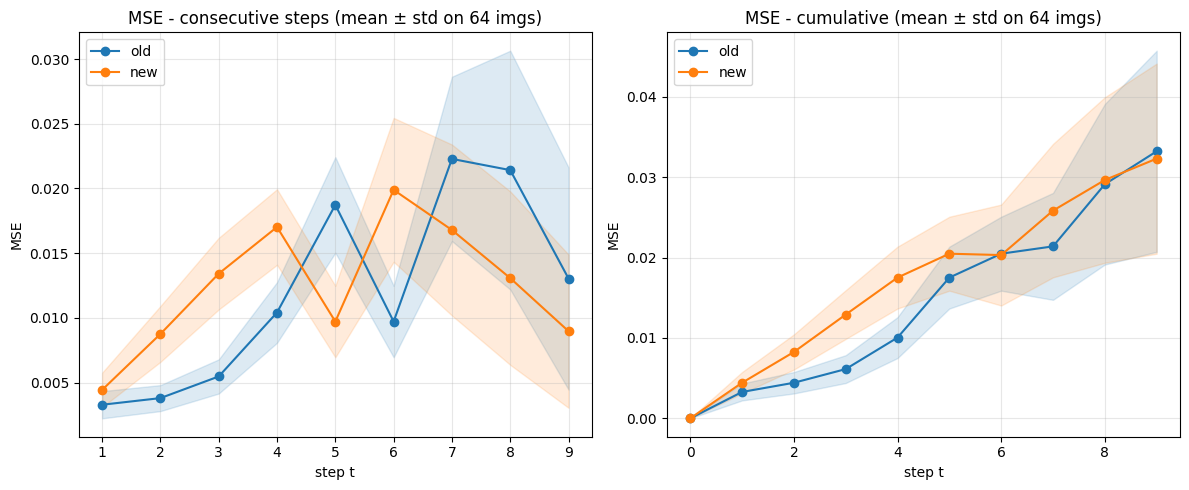

In [14]:
qualities_old = [100, 15, 11, 8, 5, 3, 2, 1, 1, 1]
qualities_1 = [100, 30, 15, 6, 5, 4, 3, 1, 1, 1]
qualities_2 = [100, 18, 10, 7, 5, 3, 1, 1, 1, 1]
qualities_3 = [100, 15, 9, 7, 5, 3, 2, 1, 1, 1]

qualities_new = [100, 11, 6, 4, 3, 2, 1, 1, 1, 1]

r_old = analyze_progression("old", qualities_old, img_batch, linear_trans = True, trans_steps=3)
r_new = analyze_progression("new", qualities_new, img_batch, linear_trans = False, trans_steps=4)
plot_comparison([r_old, r_new])

From the experiments I've concluded that there is a roof at 0.06. More degradation than that is not possible.

In [15]:
def plot_image_sequence(title, degraded_seq_tensors, qualities):
    num_images = len(degraded_seq_tensors)
    fig, axes = plt.subplots(1, num_images, figsize=(2 * num_images, 2.5))

    for i in range(num_images):
        img_tensor = degraded_seq_tensors[i]

        # Convert from B, C, H, W [-1, 1] to H, W, C [0, 1] for plotting
        plot_img = (img_tensor[0].permute(1, 2, 0).cpu().numpy() + 1) / 2

        if i == 0:
            current_title = f"Original\n(Q {qualities[0]})"
        else:
            current_title = f"Step {i}\n(Q {qualities[i]})"

        axes[i].imshow(plot_img.clip(0,1))
        axes[i].set_title(current_title, fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# The 'img' variable available in the kernel state is the padded original image tensor.
# The 'qualities_old' and 'qualities_new' lists are also available.

# Re-obtain the quantization tables and image sequences
# This step is necessary because 'analyze_progression' only returns MSE values, not the image sequences.
qt_old = build_quant_tables(qualities_old, linear_trans=True, trans_steps=3)
seq_old = generate_sequence(img_batch, len(qualities_old), qt_old)

qt_new = build_quant_tables(qualities_new, linear_trans=False, trans_steps=4)
seq_new = generate_sequence(img_batch, len(qualities_new), qt_new)

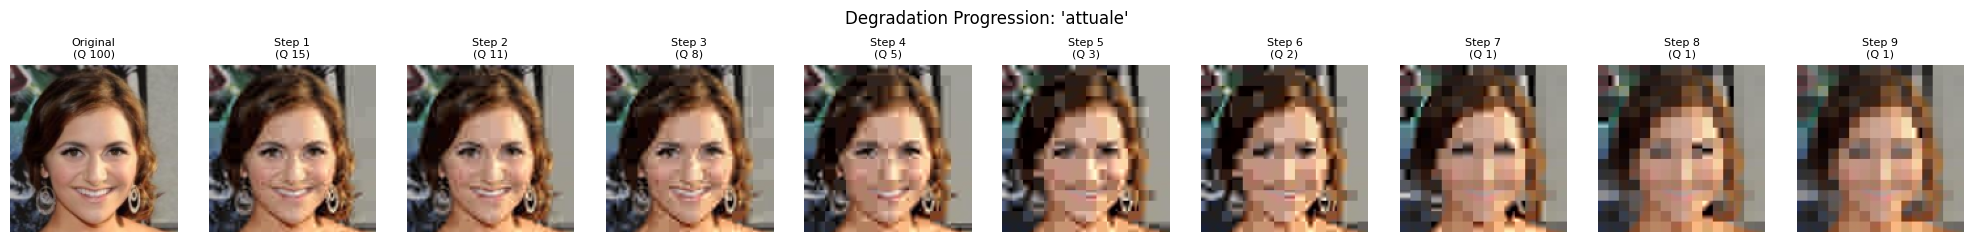

In [16]:
# Plot for old qualities
plot_image_sequence("Degradation Progression: 'attuale'", seq_old, qualities_old)

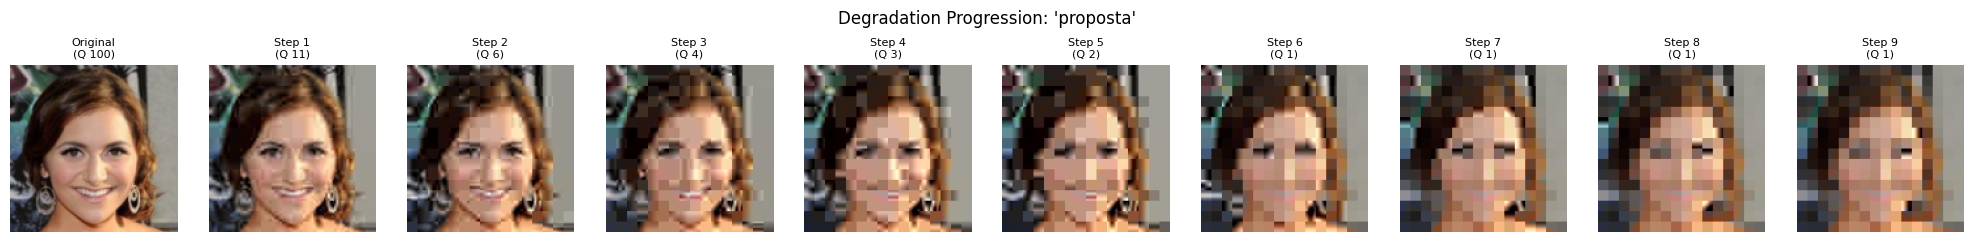

In [17]:
# Plot for new qualities
plot_image_sequence("Degradation Progression: 'proposta'", seq_new, qualities_new)

In [18]:
for i in range(len(qualities_new)):
    print(f"Quality {qualities_new[i]}:")
    # Access luminance and chrominance tables for the current step
    luminance_key = f'step{i}_luminance'
    chrominance_key = f'step{i}_chrominance'
    if luminance_key in qt_new:
        print(f"  Luminance Table:\n{qt_new[luminance_key]}")
    if chrominance_key in qt_new:
        print(f"  Chrominance Table:\n{qt_new[chrominance_key]}")

Quality 100:
  Luminance Table:
tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
  Chrominance Table:
tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
Quality 11:
  Luminance Table:
tensor([[ 73.,  50.,  45.,  73., 109., 182., 232., 255.],
        [ 54.,  54.,  64.,  86., 118., 255., 255., 250.],
        [ 64.,  59.,  73., 109., 182., 255., 255., 254.],
        [ 64.,  77., 100., 132., 232., 255., 255., 255.],
        [ 

In [19]:
# torch.save(qt_new, SAVE_PATH)
# print(f"Quantization tables 'proposta' saved to: {SAVE_PATH}")

In [20]:
def plot_one_qt(results: list[dict], out_path: str = "mse_comparison.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    steps = list(range(len(results["qualities"])))

    cons_steps = steps[1:]
    cons_mean = [v.mean().item() for v in results["mse_consecutive"][1:]]
    cons_std  = [v.std().item()  for v in results["mse_consecutive"][1:]]

    from_mean = [v.mean().item() for v in results["mse_from_start"]]
    from_std  = [v.std().item()  for v in results["mse_from_start"]]

    line, = axes[0].plot(cons_steps, cons_mean, marker="o", label=results["name"])
    axes[0].fill_between(cons_steps,
                          [m - s for m, s in zip(cons_mean, cons_std)],
                          [m + s for m, s in zip(cons_mean, cons_std)],
                          color=line.get_color(), alpha=0.15)

    line, = axes[1].plot(steps, from_mean, marker="o", label=results["name"])
    axes[1].fill_between(steps,
                          [m - s for m, s in zip(from_mean, from_std)],
                          [m + s for m, s in zip(from_mean, from_std)],
                          color=line.get_color(), alpha=0.15)

    axes[0].set_title("MSE - consecutive steps (mean ± std on 64 imgs)")
    axes[0].set_xlabel("step t"); axes[0].set_ylabel("MSE"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title("MSE - cumulative (mean ± std on 64 imgs)")
    axes[1].set_xlabel("step t"); axes[1].set_ylabel("MSE"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"\nGrafico salvato in {out_path}")

In [21]:
# OUTPUT_IMG = os.path.join(OUTPUT_DIR, "mse_new.png")
# plot_one_qt(r_new, OUTPUT_IMG)

Plot saved to /content/drive/MyDrive/Colab Notebooks/tesi/outputs/tables/mse_from_x0.png


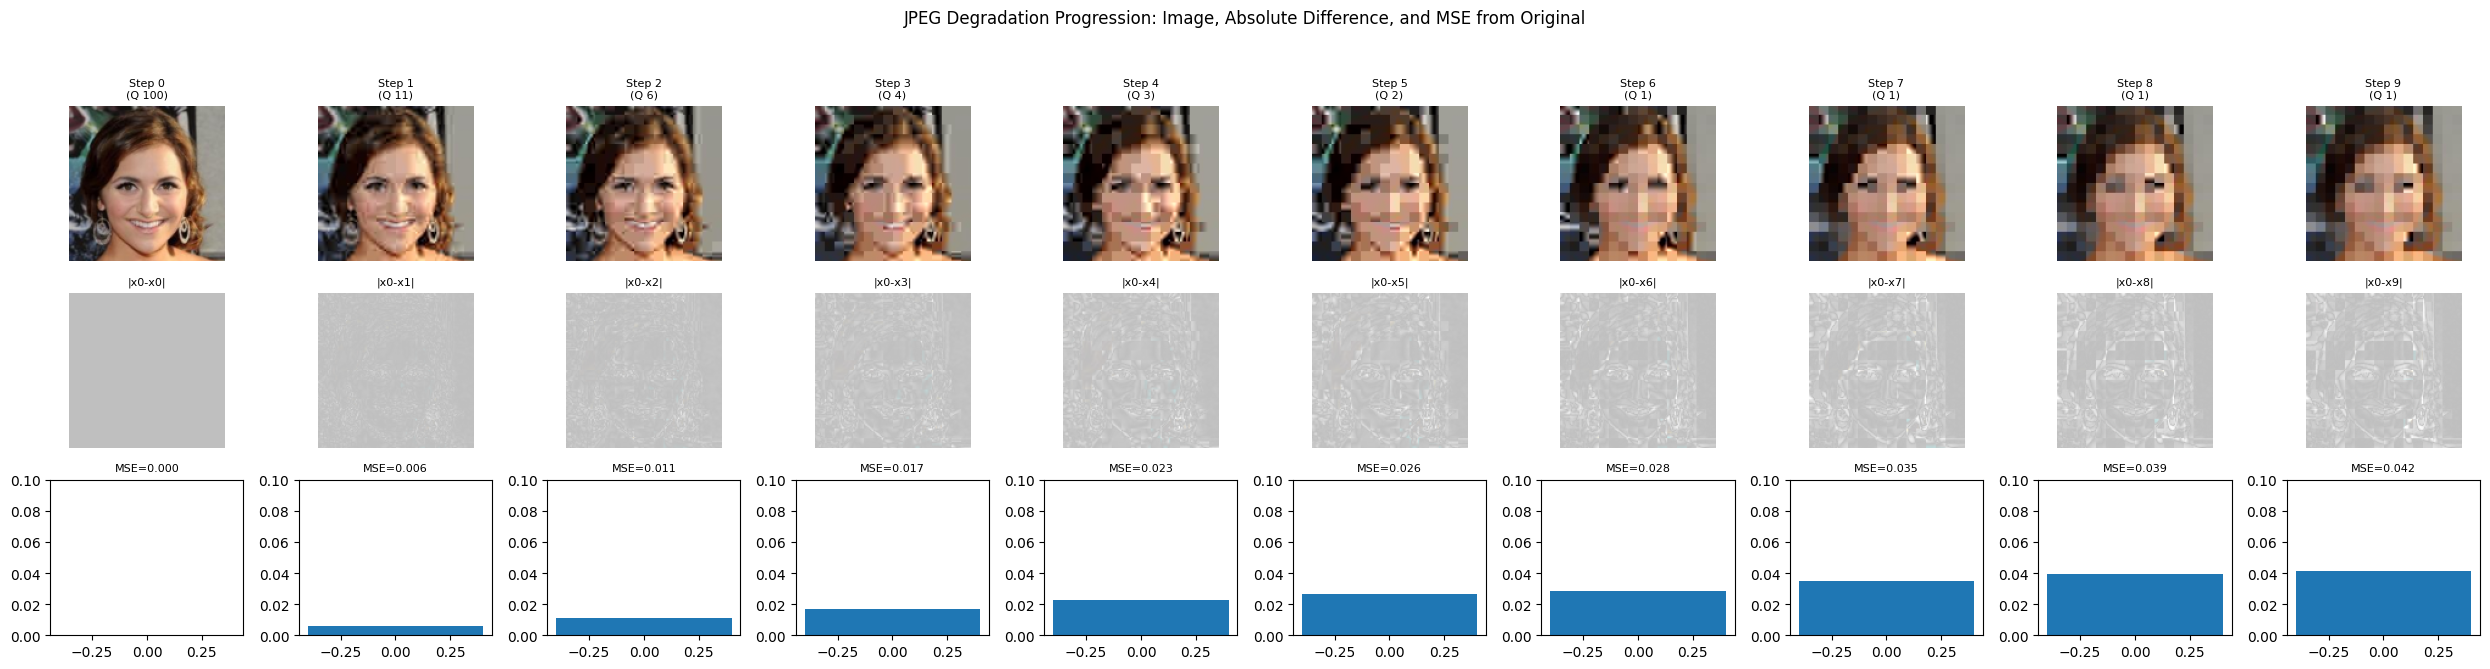

In [26]:
OUTPUT_IMG = os.path.join(OUTPUT_DIR, "mse_from_x0.png")


# Define to_display helper function for plotting
def to_display(img_tensor):
    # Convert from C, H, W [-1, 1] to H, W, C [0, 1] for plotting
    return (img_tensor.permute(1, 2, 0).cpu().numpy() + 1) / 2

# Select the first image from the batch for detailed visualization
x_0_single = img_batch[0].clone()

# Get the number of degradation steps from the pre-computed sequence
num_steps = len(seq_new)

# Create subplots: 3 rows (Degraded Image, Absolute Difference, MSE), num_steps columns
fig, axes = plt.subplots(3, num_steps, figsize=(2.5 * num_steps, 7))

# Loop through each step in the degradation sequence
for i in range(num_steps):
    # Get the degraded image for the current step (first image of the batch in sequence)
    current_degraded_img = seq_new[i][0]
    current_quality = qualities_new[i]

    # Row 0: Plot the degraded image
    axes[0, i].imshow(to_display(current_degraded_img).clip(0, 1))
    axes[0, i].set_title(f"Step {i}\n(Q {current_quality})", fontsize=8)
    axes[0, i].axis('off')

    # Row 1: Plot the absolute difference from the original image
    # Scale difference to [0,1] for display, with 0.5 being zero difference (gray)
    diff_img = (x_0_single - current_degraded_img).abs()
    axes[1, i].imshow(to_display(diff_img / 2 + 0.5).clip(0, 1))
    axes[1, i].set_title(f"|x0-x{i}|", fontsize=8)
    axes[1, i].axis('off')

    # Row 2: Plot the Mean Squared Error (MSE) from the original image
    current_mse = compute_mse_per_image(x_0_single.unsqueeze(0), current_degraded_img.unsqueeze(0)).item()
    axes[2, i].bar([0], [current_mse])
    axes[2, i].set_title(f"MSE={current_mse:.3f}", fontsize=8)
    axes[2, i].set_ylim(0, 0.1) # Set consistent y-limit for MSE plots

# Adjust overall plot layout
plt.suptitle("JPEG Degradation Progression: Image, Absolute Difference, and MSE from Original", fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(OUTPUT_IMG, dpi=150)
print(f"Plot saved to {OUTPUT_IMG}")
plt.show()